In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image= cv2.imread("/mnt/e/Image processing and computer vision using OpenCV/class.vision-master/images/balloon.png")
image.shape

(278, 372, 3)

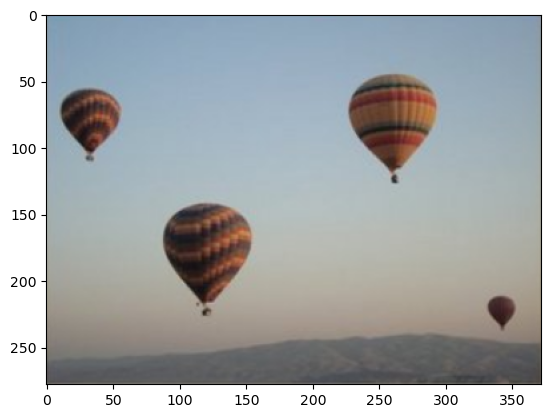

In [3]:
plt.imshow(image[..., ::-1])

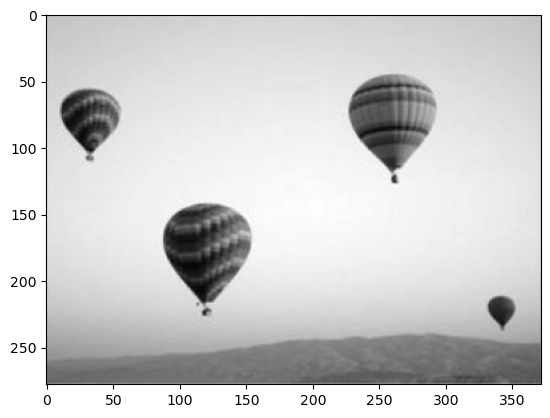

In [4]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap='gray')

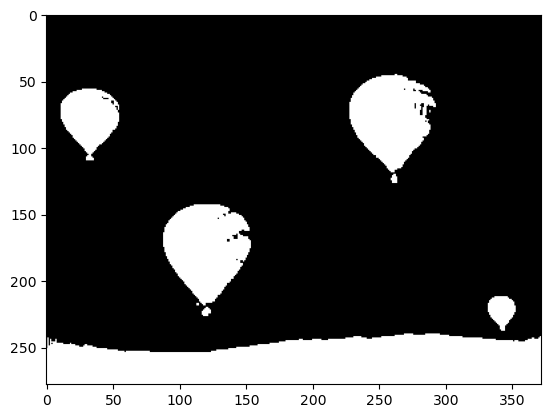

In [6]:
ret, thresh = cv2.threshold(image_gray, 128, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh, cmap='gray')

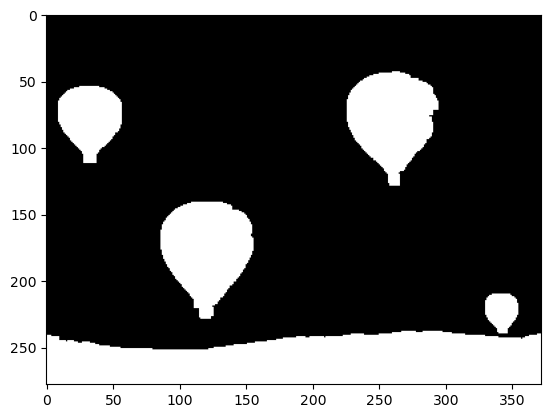

In [12]:
kernel = np.ones((5, 5), dtype=np.uint8)
dilated = cv2.dilate(thresh, kernel=kernel, iterations=1)

plt.imshow(dilated, cmap='gray')

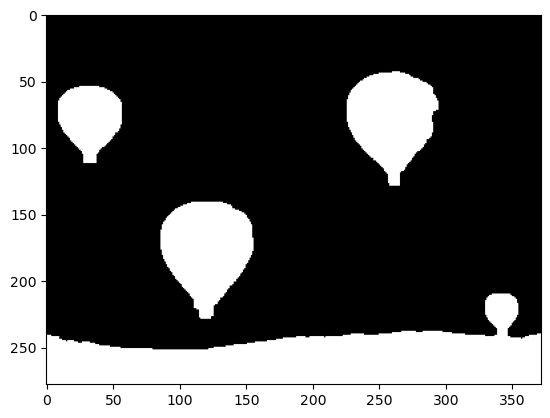

In [14]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5), (2, 2))
closed = cv2.morphologyEx(dilated, cv2.MORPH_CLOSE, kernel=kernel)

plt.imshow(closed, cmap='gray')

In [15]:
cuntours, _ = cv2.findContours(closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
print(len(cuntours))

4


In [16]:
cuntours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
print(len(cuntours))

5


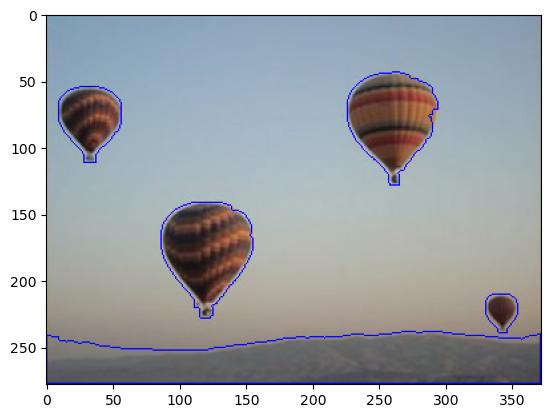

In [25]:
all_cuntours = cv2.drawContours(image, cuntours, 0, color=(255, 0, 0))
plt.imshow(image[..., ::-1])

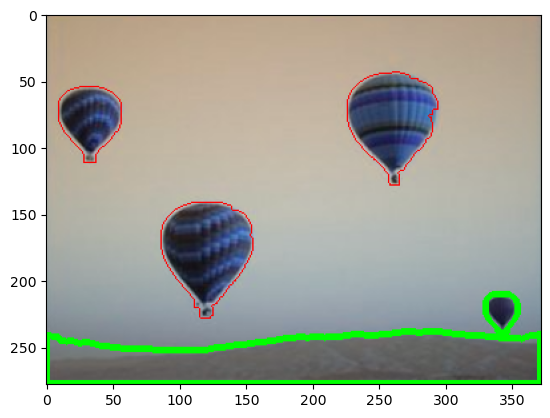

In [27]:
cv2.drawContours(image, [cuntours[1]], -1, color=(0, 255, 0), thickness=3)
plt.imshow(image)

In [28]:
image= cv2.imread("/mnt/e/Image processing and computer vision using OpenCV/class.vision-master/images/balloon.png")

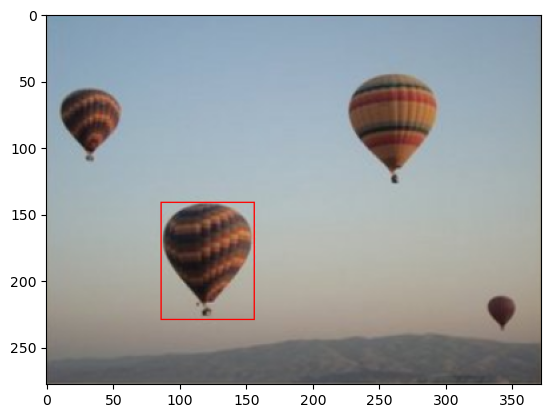

In [30]:
x, y, w, h = cv2.boundingRect(cuntours[2])
cv2.rectangle(image, (x, y), (x+w, y+h), color=(0, 0, 255))
plt.imshow(image[..., ::-1])

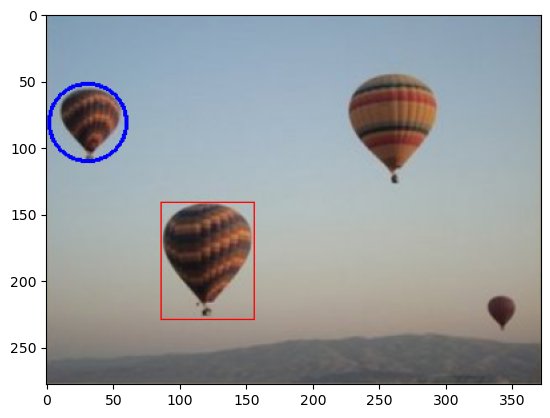

In [34]:
(x, y), r = cv2.minEnclosingCircle(cuntours[3])

center = (int(x), int(y))
radius = int(r)

cv2.circle(image, center, radius, (255, 0, 0), 2)

plt.imshow(image[..., ::-1])
plt.show()